In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression

# 2 datasets used through the notebook
cancer = load_breast_cancer()
x, y = cancer.data, cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler().fit(x_train)
x_train_s, x_test_s = sc.transform(x_train), sc.transform(x_test)
print("Ready:", x_train.shape, x_test.shape)

Ready: (455, 30) (114, 30)


7. Model Evaluation

7.1 Classification Metrics

In [93]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,
                             RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay)

clf = LogisticRegression(max_iter=1000).fit(x_train_s, y_train)
y_pred = clf.predict(x_test_s)
y_proba = clf.predict_proba(x_test_s)[:, 1]         #probability of class 1 (benign)

print("Accuracy:",     round(accuracy_score(y_test, y_pred), 3))
print("Precision:",       round(precision_score(y_test, y_pred), 3))
print("Recall:",           round(recall_score(y_test, y_pred), 3))
print("F1:",            round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:",        round(roc_auc_score(y_test, y_pred), 3))   #needs probabilities, not labels

Accuracy: 0.982
Precision: 0.986
Recall: 0.986
F1: 0.986
ROC-AUC: 0.981


7.2 Confusion Matrix

TN=41, FP=1, FN=1, TP=71


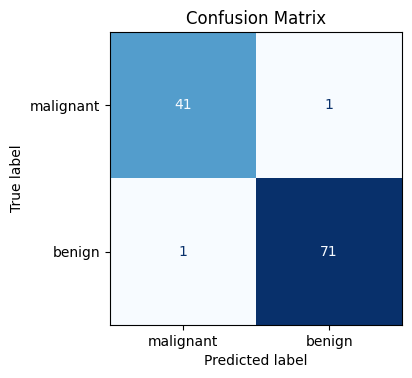

In [94]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

fig, ax = plt.subplots(figsize=(4.2, 3.8))
ConfusionMatrixDisplay(cm, display_labels=cancer.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

7.3 'classification_report': precision, recall, f1 for every class at once

In [95]:
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



7.4 ROC curve and Precision-recall curve

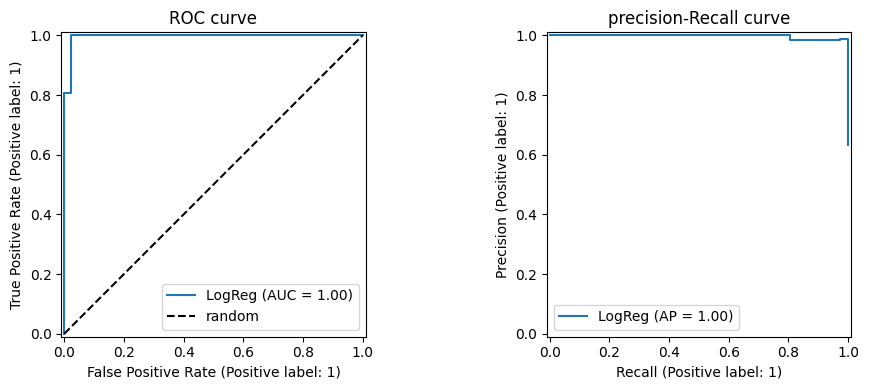

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0], name="LogReg")
ax[0].plot([0, 1], [0, 1], "k--", label="random")
ax[0].set_title("ROC curve")
ax[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[1], name="LogReg")
ax[1].set_title("precision-Recall curve")
plt.tight_layout()
plt.show()


7.5 Imbalanced data: why accuracy fails, and what to do

In [97]:
Xi, yi = make_classification(n_samples=4000, n_features=10, n_informative=5,
                             weights=[0.95, 0.05], random_state=0)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.25, stratify=yi, random_state=0)
print("Positive rate:", yi.mean().round(3))

# A useless model that always predicts 0
always0 = np.zeros_like(yi_te)
print("Always-0  -> accuracy:", round(accuracy_score(yi_te, always0), 3),
      "| recall:", recall_score(yi_te, always0))

# Plain logistic regression
m_plain = LogisticRegression(max_iter=1000).fit(Xi_tr, yi_tr)
# class_weight='balanced' penalises mistakes on the rare class more
m_bal   = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xi_tr, yi_tr)

for name, m in [("plain   ", m_plain), ("balanced", m_bal)]:
    p = m.predict(Xi_te)
    print(f"{name} -> acc {accuracy_score(yi_te, p):.3f} | precision {precision_score(yi_te, p):.3f} "
          f"| recall {recall_score(yi_te, p):.3f} | F1 {f1_score(yi_te, p):.3f}")

Positive rate: 0.055
Always-0  -> accuracy: 0.945 | recall: 0.0
plain    -> acc 0.969 | precision 0.833 | recall 0.545 | F1 0.659
balanced -> acc 0.884 | precision 0.298 | recall 0.818 | F1 0.437


7.6 Changing the decision threshold

In [98]:
proba = m_plain.predict_proba(Xi_te)[:, 1]
rows = []
for th in [0.5, 0.3, 0.2, 0.1]:
    p = (proba >= th).astype(int)
    rows.append({"threshold": th, "precision": precision_score(yi_te, p),
                 "recall": recall_score(yi_te, p), "F1": f1_score(yi_te, p)})
pd.DataFrame(rows)

,threshold,precision,recall,F1
0,0.5,0.833,0.545,0.659
1,0.3,0.733,0.600,0.660
2,0.2,0.629,0.709,0.667
3,0.1,0.454,0.800,0.579


7.7 Regression Metrics

MAE : 42.79
MSE : 2900.19
RMSE: 53.85
R2  : 0.453


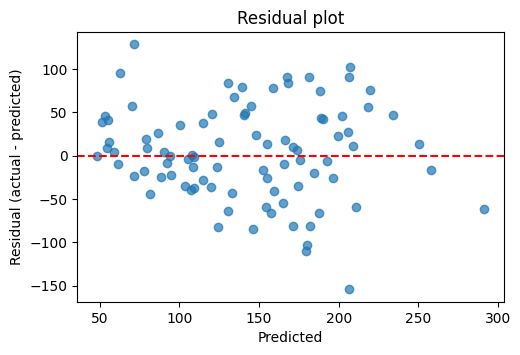

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Xd, yd = load_diabetes(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.2, random_state=42)
reg = LinearRegression().fit(Xd_tr, yd_tr)
pr = reg.predict(Xd_te)

print("MAE :", round(mean_absolute_error(yd_te, pr), 2))
print("MSE :", round(mean_squared_error(yd_te, pr), 2))
print("RMSE:", np.sqrt(mean_squared_error(yd_te, pr)).round(2))
print("R2  :", round(r2_score(yd_te, pr), 3))

# Residual plot: errors should be scattered randomly around 0
plt.figure(figsize=(5.5, 3.5))
plt.scatter(pr, yd_te - pr, alpha=0.7)
plt.axhline(0, color="r", ls="--")
plt.xlabel("Predicted")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot")
plt.show()

7.8 Cross-validation

In [100]:
from sklearn.model_selection import cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))   # scaler inside CV = no leakage

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=skf, scoring="accuracy")
print("Fold scores:", scores.round(3))
print(f"Mean {scores.mean():.3f}  +/- {scores.std():.3f}")

Fold scores: [0.974 0.947 0.965 0.991 0.991]
Mean 0.974  +/- 0.017


In [101]:
# cross_validate: several metrics at once + train scores + timings
res = cross_validate(model, x, y, cv=skf,
                     scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
                     return_train_score=True)
summary = pd.DataFrame({k: v for k, v in res.items() if k.startswith(("test_", "train_"))})
summary.mean().round(3)

test_accuracy      0.974
train_accuracy     0.988
test_precision     0.968
train_precision    0.986
test_recall        0.992
train_recall       0.995
test_f1            0.979
train_f1           0.991
test_roc_auc       0.995
train_roc_auc      0.998
dtype: float64

         mean    std
SVM     0.977  0.018
LogReg  0.974  0.019
KNN     0.963  0.020
Forest  0.954  0.011
Tree    0.916  0.019


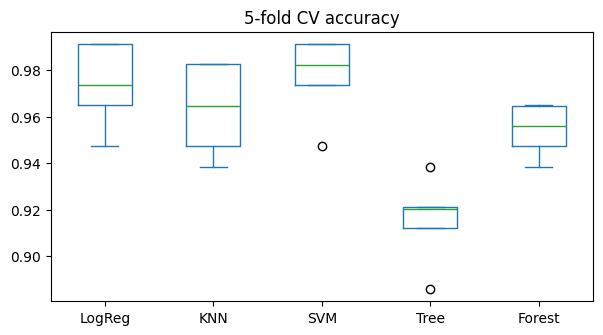

In [102]:
# Compare several models fairly with the same folds
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

candidates = {
    "LogReg":  make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN":     make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM":     make_pipeline(StandardScaler(), SVC()),
    "Tree":    DecisionTreeClassifier(random_state=0),
    "Forest":  RandomForestClassifier(random_state=0),
}
cv_table = pd.DataFrame({n: cross_val_score(m, x, y, cv=skf) for n, m in candidates.items()})
print(cv_table.agg(["mean", "std"]).T.round(3).sort_values("mean", ascending=False))

cv_table.plot(kind="box", figsize=(7, 3.5), title="5-fold CV accuracy"); plt.show()

7.9 Learning curve and Validation Curve: diagonize over/underfitting

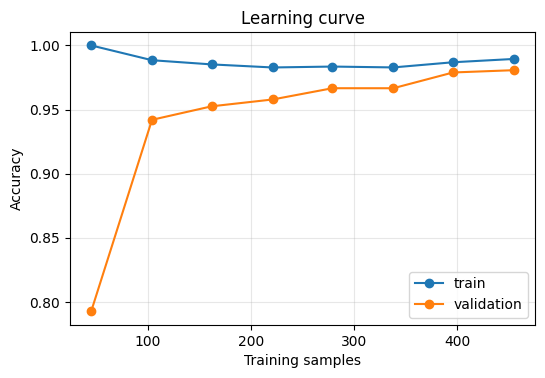

In [103]:
from sklearn.model_selection import learning_curve, validation_curve

sizes, tr, va = learning_curve(model, x, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy")
plt.figure(figsize=(6, 3.8))
plt.plot(sizes, tr.mean(axis=1), "o-", label="train")
plt.plot(sizes, va.mean(axis=1), "o-", label="validation")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

8.Hyperparameter tuning

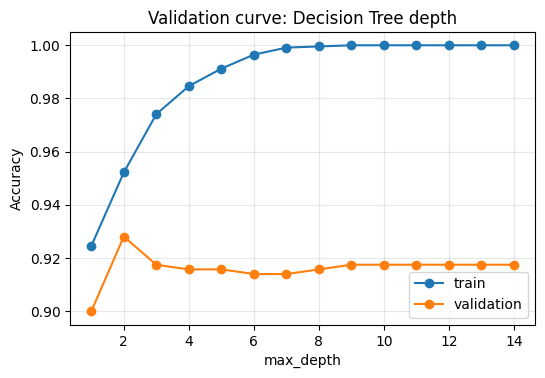

Best depth on validation: 2


In [104]:
depths = np.arange(1, 15)
tr, va = validation_curve(DecisionTreeClassifier(random_state=0), x, y,
                          param_name="max_depth", param_range=depths, cv=5)
plt.figure(figsize=(6, 3.8))
plt.plot(depths, tr.mean(axis=1), "o-", label="train")
plt.plot(depths, va.mean(axis=1), "o-", label="validation")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Validation curve: Decision Tree depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("Best depth on validation:", depths[va.mean(axis=1).argmax()])

In [105]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

pipe = make_pipeline(StandardScaler(), SVC())
# Inside a pipeline, parameter names are  <step_name>__<param>. make_pipeline names steps in lowercase.
param_grid = {
    "svc__C":      [0.1, 1, 10, 100],
    "svc__gamma":  ["scale", 0.01, 0.001],
    "svc__kernel": ["rbf", "linear"],
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

t = time.time()
grid.fit(x_train, y_train)
print(f"Tried {len(grid.cv_results_['params'])} combos x 5 folds in {time.time()-t:.1f}s")
print("Best params :", grid.best_params_)
print("Best CV acc :", round(grid.best_score_, 3))
print("Test acc    :", round(grid.score(x_test, y_test), 3))   # uses the best model, refit on all train data

Tried 24 combos x 5 folds in 0.6s
Best params : {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV acc : 0.98
Test acc    : 0.982


In [106]:
# Look at all results
res = pd.DataFrame(grid.cv_results_)
cols = ["param_svc__C", "param_svc__gamma", "param_svc__kernel", "mean_test_score", "std_test_score", "rank_test_score"]
res[cols].sort_values("rank_test_score").head(8)

,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_score,std_test_score,rank_test_score
14,10.0,0.01,rbf,0.980,0.016,1
1,0.1,scale,linear,0.978,0.014,2
5,0.1,0.001,linear,0.978,0.014,2
3,0.1,0.01,linear,0.978,0.014,2
22,100.0,0.001,rbf,0.978,0.016,2
16,10.0,0.001,rbf,0.974,0.015,6
12,10.0,scale,rbf,0.971,0.018,7
6,1.0,scale,rbf,0.971,0.018,7


In [107]:
# best_estimator_ is the ready-to-use fitted model
best = grid.best_estimator_
print(best)
print("Prediction for first 5 test rows:", best.predict(x_test[:5]))

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=10, gamma=0.01))])
Prediction for first 5 test rows: [0 1 0 1 0]


8.2 RandomizedsearchCV

In [108]:
from scipy.stats import randint, loguniform
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators":      randint(50, 400),
    "max_depth":         randint(2, 20),
    "min_samples_split": randint(2, 12),
    "min_samples_leaf":  randint(1, 8),
    "max_features":      ["sqrt", "log2", None],
}
rand = RandomizedSearchCV(RandomForestClassifier(random_state=0), param_dist,
                          n_iter=25, cv=5, scoring="f1", random_state=42, n_jobs=-1)

t = time.time()
rand.fit(x_train, y_train)
print(f"25 random combos in {time.time()-t:.1f}s")
print("Best params:", rand.best_params_)
print("Best CV F1 :", round(rand.best_score_, 3))
print("Test F1    :", round(f1_score(y_test, rand.predict(x_test)), 3))

25 random combos in 16.5s
Best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 9, 'n_estimators': 238}
Best CV F1 : 0.967
Test F1    : 0.966


8.3 Tuning tips

In [109]:
# Example: tune for recall (catch as many positives as possible) on the imbalanced data
g = GridSearchCV(LogisticRegression(max_iter=2000, class_weight="balanced"),
                 {"C": [0.01, 0.1, 1, 10]}, scoring="recall", cv=5)
g.fit(Xi_tr, yi_tr)
print("Best C:", g.best_params_, "| CV recall:", round(g.best_score_, 3))

Best C: {'C': 0.01} | CV recall: 0.782


9. Pipelines and ColumnTransformer

In [110]:
rng = np.random.default_rng(42)
n = 1500
df = pd.DataFrame({
    "age":       rng.integers(18, 70, n).astype(float),
    "income":    rng.normal(50000, 15000, n).round(0),
    "tenure":    rng.integers(0, 10, n).astype(float),
    "city":      rng.choice(["Pune", "Mumbai", "Delhi", "Nagpur"], n),
    "plan":      rng.choice(["basic", "standard", "premium"], n, p=[0.5, 0.3, 0.2]),
    "complaints": rng.poisson(1.2, n).astype(float),
})
# Target depends on some columns + noise
logit = 0.9*df["complaints"] - 0.25*df["tenure"] + (df["plan"] == "basic")*0.8 - (df["income"]-50000)/40000 - 0.5
df["churn"] = (rng.random(n) < 1/(1+np.exp(-logit))).astype(int)

# Inject missing values
for col in ["age", "income", "city"]:
    df.loc[rng.choice(n, 120, replace=False), col] = np.nan

print(df.head())
print("\nMissing:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nChurn rate:", df["churn"].mean().round(3))

    age   income  tenure    city      plan  complaints  churn
0   NaN  48557.0     5.0  Mumbai   premium         4.0      1
1   NaN  66920.0     6.0  Mumbai   premium         3.0      0
2  52.0  15789.0     9.0  Mumbai  standard         2.0      1
3   NaN  27550.0     6.0   Delhi   premium         2.0      1
4  40.0      NaN     4.0   Delhi  standard         0.0      1

Missing:
 age       120
income    120
city      120
dtype: int64

Churn rate: 0.482


In [111]:
Xdf = df.drop(columns="churn")
ydf = df["churn"]
Xdf_tr, Xdf_te, ydf_tr, ydf_te = train_test_split(Xdf, ydf, test_size=0.2, random_state=42, stratify=ydf)

9.1 ColumnTransformer: different preprocessing for differnt columns 

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

num_cols = ["age", "income", "tenure", "complaints"]
cat_cols = ["city"]
ord_cols = ["plan"]

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot",  OneHotEncoder(handle_unknown="ignore"))])
ord_pipe = Pipeline([("ordinal", OrdinalEncoder(categories=[["basic", "standard", "premium"]]))])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
    ("ord", ord_pipe, ord_cols),
])

full_pipe = Pipeline([("prep", preprocess),
                      ("model", LogisticRegression(max_iter=1000))])

full_pipe.fit(Xdf_tr, ydf_tr)                       # raw DataFrame with NaNs and text goes straight in
print("Test accuracy:", round(full_pipe.score(Xdf_te, ydf_te), 3))
print("ROC-AUC      :", round(roc_auc_score(ydf_te, full_pipe.predict_proba(Xdf_te)[:, 1]), 3))

Test accuracy: 0.723
ROC-AUC      : 0.787


Output feature names: ['num__age', 'num__income', 'num__tenure', 'num__complaints', 'cat__city_Delhi', 'cat__city_Mumbai', 'cat__city_Nagpur', 'cat__city_Pune', 'ord__plan']


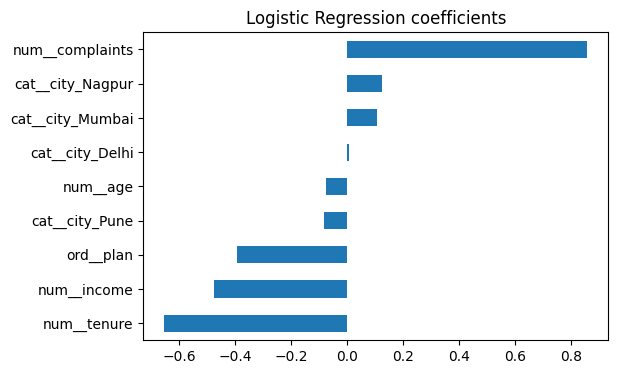

In [113]:
# See what the preprocessing produced
print("Output feature names:", list(full_pipe.named_steps["prep"].get_feature_names_out()))

# Inspect learned coefficients
names = full_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(full_pipe.named_steps["model"].coef_[0], index=names).sort_values()
coefs.plot(kind="barh", figsize=(6, 4), title="Logistic Regression coefficients")
plt.show()

9.2 predicting on brand new raw data

In [114]:
new_customer = pd.DataFrame([{
    "age": 34, "income": np.nan, "tenure": 1, "city": "Pune", "plan": "basic", "complaints": 4
}])
print("Churn probability:", full_pipe.predict_proba(new_customer)[0, 1].round(3))
print("Prediction       :", full_pipe.predict(new_customer)[0])

Churn probability: 0.958
Prediction       : 1


9.3 'make_column_selector' : pick columns by type automatically

In [115]:
auto_prep = ColumnTransformer([
    ("num", num_pipe, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipe, make_column_selector(dtype_include=object)),
])
auto_pipe = Pipeline([("prep", auto_prep), ("model", RandomForestClassifier(n_estimators=200, random_state=0))])
auto_pipe.fit(Xdf_tr, ydf_tr)
print("Auto-selected pipeline accuracy:", round(auto_pipe.score(Xdf_te, ydf_te), 3))

Auto-selected pipeline accuracy: 0.693


9.4 Tune processing AND model together

In [116]:
from sklearn.preprocessing import MinMaxScaler

search_pipe = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))])

grid = {
    "prep__num__imputer__strategy": ["mean", "median"],
    "prep__num__scaler": [StandardScaler(), MinMaxScaler()],       # swap the scaler itself
    "model": [LogisticRegression(max_iter=2000), RandomForestClassifier(random_state=0)],
}
gs = GridSearchCV(search_pipe, grid, cv=5, scoring="roc_auc", n_jobs=-1)
gs.fit(Xdf_tr, ydf_tr)

print("Best config:", {k: (type(v).__name__ if not isinstance(v, str) else v) for k, v in gs.best_params_.items()})
print("CV AUC:", round(gs.best_score_, 3), "| Test AUC:", round(roc_auc_score(ydf_te, gs.predict_proba(Xdf_te)[:, 1]), 3))

Best config: {'model': 'LogisticRegression', 'prep__num__imputer__strategy': 'mean', 'prep__num__scaler': 'StandardScaler'}
CV AUC: 0.771 | Test AUC: 0.787


9.5 Why pipelines prevent data leakage(demo)

In [117]:
# WRONG way (leaky)
X_leaky = StandardScaler().fit_transform(x)
leaky = cross_val_score(LogisticRegression(max_iter=1000), X_leaky, y, cv=skf).mean()

# RIGHT way
right = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), x, y, cv=skf).mean()
print(f"Leaky: {leaky:.4f} | Correct: {right:.4f}")

# Bigger leakage example: selecting features using ALL labels, on pure-noise data
from sklearn.feature_selection import SelectKBest, f_classif
rng = np.random.default_rng(0)
Xn, yn = rng.normal(size=(100, 500)), rng.integers(0, 2, 100)      # random noise: true accuracy should be ~50%

Xn_sel = SelectKBest(f_classif, k=10).fit_transform(Xn, yn)          # selection saw the labels of ALL rows
bad = cross_val_score(LogisticRegression(), Xn_sel, yn, cv=5).mean()
good = cross_val_score(make_pipeline(SelectKBest(f_classif, k=10), LogisticRegression()), Xn, yn, cv=5).mean()
print(f"Noise data -> leaky selection: {bad:.2f} (fake!) | pipeline: {good:.2f} (honest ~0.5)")

Leaky: 0.9737 | Correct: 0.9737
Noise data -> leaky selection: 0.70 (fake!) | pipeline: 0.50 (honest ~0.5)


9.6 Custom transformer with 'FunctionTransformer'

In [118]:
from sklearn.preprocessing import FunctionTransformer

skewed = np.array([[1], [10], [100], [1000], [10000]])
log_step = FunctionTransformer(np.log1p, inverse_func=np.expm1)
print("log1p:", log_step.fit_transform(skewed).ravel().round(2))

# Inside a pipeline
p = make_pipeline(FunctionTransformer(np.log1p), StandardScaler(), LinearRegression())
print(p)

log1p: [0.69 2.4  4.62 6.91 9.21]
Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<ufunc 'log1p'>)),
                ('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])


10. Ensembles

In [119]:
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier

def cv_acc(m):  # helper: mean 5-fold accuracy on the cancer data
    return cross_val_score(m, x, y, cv=skf).mean()

print("Single Decision Tree:", round(cv_acc(DecisionTreeClassifier(random_state=0)), 3))

Single Decision Tree: 0.916


10.1 Bagging and random forest

In [120]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=0, n_jobs=-1)
rf  = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
et  = ExtraTreesClassifier(n_estimators=200, random_state=0, n_jobs=-1)   # even more random splits, often faster

for name, m in [("Bagging(trees)", bag), ("Random Forest", rf), ("Extra Trees", et)]:
    print(f"{name:15s}: {cv_acc(m):.3f}")

# Random Forest bonus: out-of-bag score = free validation without a separate split
rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=0).fit(x_train, y_train)
print("\nRandom Forest OOB score:", round(rf_oob.oob_score_, 3))

Bagging(trees) : 0.956
Random Forest  : 0.954
Extra Trees    : 0.958

Random Forest OOB score: 0.96


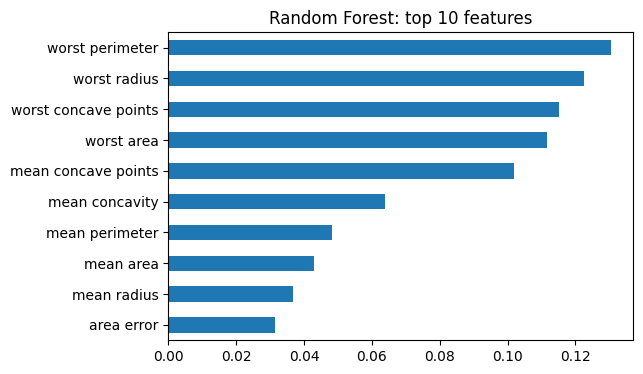

In [121]:
# Feature importance from the forest
imp = pd.Series(rf_oob.feature_importances_, index=cancer.feature_names).sort_values().tail(10)
imp.plot(kind="barh", figsize=(6, 4), title="Random Forest: top 10 features")
plt.show()

10.2 Boosting: Adaboost, Gradient Boosting, HistGradientBoosting

In [122]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=0)
gb  = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=0)
hgb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=0)

for name, m in [("AdaBoost", ada), ("GradientBoosting", gb), ("HistGradientBoosting", hgb)]:
    t = time.time(); s = cv_acc(m)
    print(f"{name:21s}: {s:.3f}  ({time.time()-t:.1f}s)")

AdaBoost             : 0.961  (3.8s)
GradientBoosting     : 0.954  (5.0s)
HistGradientBoosting : 0.954  (1.5s)


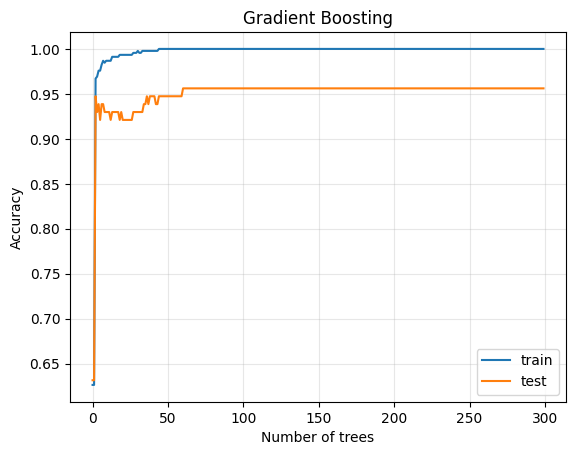

In [123]:
# How does the number of trees affect Gradient Boosting? (staged predictions = free curve)
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=0).fit(x_train, y_train)
test_acc  = [accuracy_score(y_test, p) for p in gb.staged_predict(x_test)]
train_acc = [accuracy_score(y_train, p) for p in gb.staged_predict(x_train)]

plt.plot(train_acc, label="train")
plt.plot(test_acc, label="test")
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

10.3 Voting

In [124]:
lr  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
svm = make_pipeline(StandardScaler(), SVC(probability=True, random_state=0))
rfc = RandomForestClassifier(n_estimators=200, random_state=0)

hard = VotingClassifier([("lr", lr), ("svm", svm), ("rf", rfc)], voting="hard")
soft = VotingClassifier([("lr", lr), ("svm", svm), ("rf", rfc)], voting="soft")

print("LogReg :", round(cv_acc(lr), 3))
print("SVM    :", round(cv_acc(svm), 3))
print("Forest :", round(cv_acc(rfc), 3))
print("Hard vote:", round(cv_acc(hard), 3))
print("Soft vote:", round(cv_acc(soft), 3))

LogReg : 0.974
SVM    : 0.977
Forest : 0.954
Hard vote: 0.982
Soft vote: 0.981


10.4 Stacking

In [125]:
stack = StackingClassifier(
    estimators=[("lr", lr), ("svm", svm), ("rf", rfc)],
    final_estimator=LogisticRegression(),
    cv=5,
)
print("Stacking:", round(cv_acc(stack), 3))

Stacking: 0.981


10.5 Final comparision of everything

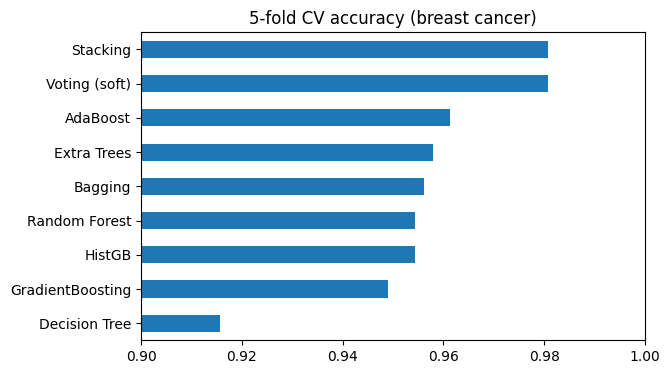

Voting (soft)       0.981
Stacking            0.981
AdaBoost            0.961
Extra Trees         0.958
Bagging             0.956
Random Forest       0.954
HistGB              0.954
GradientBoosting    0.949
Decision Tree       0.916
dtype: float64


In [126]:
everything = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Bagging": bag, "Random Forest": rf, "Extra Trees": et,
    "AdaBoost": ada, "GradientBoosting": GradientBoostingClassifier(random_state=0), "HistGB": hgb,
    "Voting (soft)": soft, "Stacking": stack,
}
final = pd.Series({n: cv_acc(m) for n, m in everything.items()}).sort_values()
final.plot(kind="barh", figsize=(6.5, 4), xlim=(0.90, 1.0), title="5-fold CV accuracy (breast cancer)")
plt.show()
print(final.round(3).sort_values(ascending=False))

11. Saving and Loading Models

In [127]:
import joblib, pickle, os, json, sklearn
from pathlib import Path

out = Path("saved_models"); out.mkdir(exist_ok=True)

# Save the full churn pipeline (imputer + scaler + encoder + model)
best_pipe = gs.best_estimator_
joblib.dump(best_pipe, out / "churn_pipeline.joblib")
print("Saved:", (out / "churn_pipeline.joblib").name, "|", round(os.path.getsize(out / "churn_pipeline.joblib") / 1024, 1), "KB")

Saved: churn_pipeline.joblib | 4.8 KB


In [128]:
# Load it back (imagine this is a different script or app)
loaded = joblib.load(out / "churn_pipeline.joblib")

new_customers = pd.DataFrame([
    {"age": 45, "income": 82000, "tenure": 8, "city": "Delhi",  "plan": "premium", "complaints": 0},
    {"age": 29, "income": 31000, "tenure": 0, "city": "Nagpur", "plan": "basic",   "complaints": 5},
])
print("Churn probability:", loaded.predict_proba(new_customers)[:, 1].round(3))

# Proof it's identical to the original
same = np.allclose(best_pipe.predict_proba(Xdf_te)[:, 1], loaded.predict_proba(Xdf_te)[:, 1])
print("Loaded model gives identical predictions:", same)

Churn probability: [0.03  0.994]
Loaded model gives identical predictions: True


pickle version + compression

In [129]:
with open(out / "churn_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipe, f)
with open(out / "churn_pipeline.pkl", "rb") as f:
    from_pickle = pickle.load(f)
print("Pickle works:", np.allclose(from_pickle.predict_proba(Xdf_te)[:, 1], best_pipe.predict_proba(Xdf_te)[:, 1]))

# joblib can compress big models (e.g. large Random Forests)
big = RandomForestClassifier(n_estimators=300, random_state=0).fit(x_train, y_train)
joblib.dump(big, out / "big_rf.joblib")
joblib.dump(big, out / "big_rf_compressed.joblib", compress=3)
for f in ["big_rf.joblib", "big_rf_compressed.joblib"]:
    print(f"{f:26s} {os.path.getsize(out / f) / 1024:.0f} KB")

Pickle works: True
big_rf.joblib              949 KB
big_rf_compressed.joblib   185 KB


save metadata too

In [130]:
meta = {
    "model": "churn_pipeline",
    "sklearn_version": sklearn.__version__,
    "trained_rows": int(len(Xdf_tr)),
    "test_roc_auc": round(float(roc_auc_score(ydf_te, best_pipe.predict_proba(Xdf_te)[:, 1])), 4),
    "input_columns": list(Xdf.columns),
}
(out / "churn_pipeline_meta.json").write_text(json.dumps(meta, indent=2))
print(json.dumps(meta, indent=2))

{
  "model": "churn_pipeline",
  "sklearn_version": "1.7.2",
  "trained_rows": 1200,
  "test_roc_auc": 0.7873,
  "input_columns": [
    "age",
    "income",
    "tenure",
    "city",
    "plan",
    "complaints"
  ]
}
